# Tree analysis


## Setup


In [1]:
import os, re
import numpy as np
import pandas as pd
import analysis_lib as A
from analysis_lib import (
    MORL_METHODS, MOEA_METHODS, ORDER,
    METHOD_LABEL, PARADIGM_OF, PARADIGM_COLOR, N_OBJS_DEFAULT,
)

N_OBJS = N_OBJS_DEFAULT  # [2, 6]

METRICS = [
    dict(col='hv_ratio',     base='hv_ratio',
         ylabel='HV (normalised)',      better='higher'),
    dict(col='spacing_norm', base='spacing_norm',
         ylabel='spacing (normalised)', better='lower'),
]

## Deterministic


### Configuration
Paths, condition vocabulary, and folder regexes specific to the deterministic-tree setting.


In [2]:
MORL_CSV = '../data/tree/deterministic/morl/metrics_long_reeval.csv'
MOEA_CSV = '../data/tree/deterministic/moea/metrics_long_reeval.csv'
OUT_DIR  = './tree_figures'

CONDITION_STYLE = {
    'closed_loop_single':       dict(alpha=0.55, hatch=''),
    'intertemporal_observable': dict(alpha=0.55, hatch=''),
    'table_observable':         dict(alpha=0.35, hatch=''),
    'table_non_observable':     dict(alpha=0.25, hatch='////'),
}
CONDITION_LABEL = {
    'intertemporal_observable':  'intertemporal · fully_obs.',
    'table_observable':          'table · fully_obs.',
    'table_non_observable':      'table · not_fully_obs.',
    'closed_loop_single':        'Q-table',
}
CONDITION_ORDER = [
    'closed_loop_single',
    'intertemporal_observable',
    'table_observable',
    'table_non_observable',
]

MOEA_FOLDER_RE = re.compile(
    r'^(intertemporal|table)_(NSGAII|IBEA|MOEAD)_single_'
    r'(\d+)_(observable|non_observable)$')
MORL_FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_single_(\d+)$')

def moea_fmt(groups):
    policy, algo, n_obj, observability = groups
    return f'{policy}_{observability}', algo, int(n_obj)

def morl_fmt(groups):
    scoring, n_obj = groups
    return 'closed_loop_single', scoring, int(n_obj)

### Load + summary


In [3]:
df = A.load_metrics(MORL_CSV, MOEA_CSV, metrics=METRICS)
A.print_metric_summary(df, metrics=METRICS, n_objs=N_OBJS,
                       condition_order=CONDITION_ORDER)

paradigm method        condition                    n_obj    n        n_dom     ±std        hv_ratio      ±std    spacing_norm      ±std
MORL     PQL-Pareto    closed_loop_single               2   10          0.0      0.0         0.78308   0.00011         0.00137   0.00006
MORL     PQL-Indicator closed_loop_single               2   10          0.0      0.0         0.78318   0.00001         0.00135   0.00001
MORL     PQL-Decomp    closed_loop_single               2   10          0.0      0.0         0.78138   0.00000         0.00697   0.00000
MOEA     NSGA-II       intertemporal_observable         2   10          0.0      0.0         0.78318   0.00001         0.00141   0.00003
MOEA     NSGA-II       table_observable                 2   10          0.0      0.0         0.78318   0.00000         0.00140   0.00001
MOEA     NSGA-II       table_non_observable             2   10          0.0      0.0         0.61255   0.00000         0.04264   0.00004
MOEA     IBEA          intertemporal_obse

### Figure 1 — HV ratio + spacing (box plots)


Saved ./tree_figures/fig3_det_tree_hv_ratio.png
Saved ./tree_figures/fig3_det_tree_spacing_norm.png


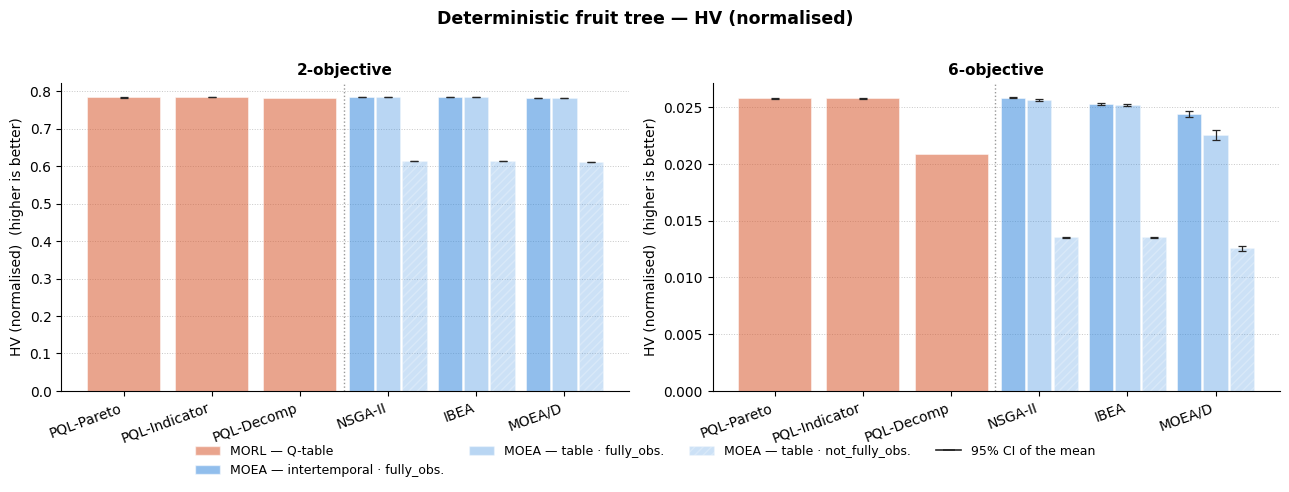

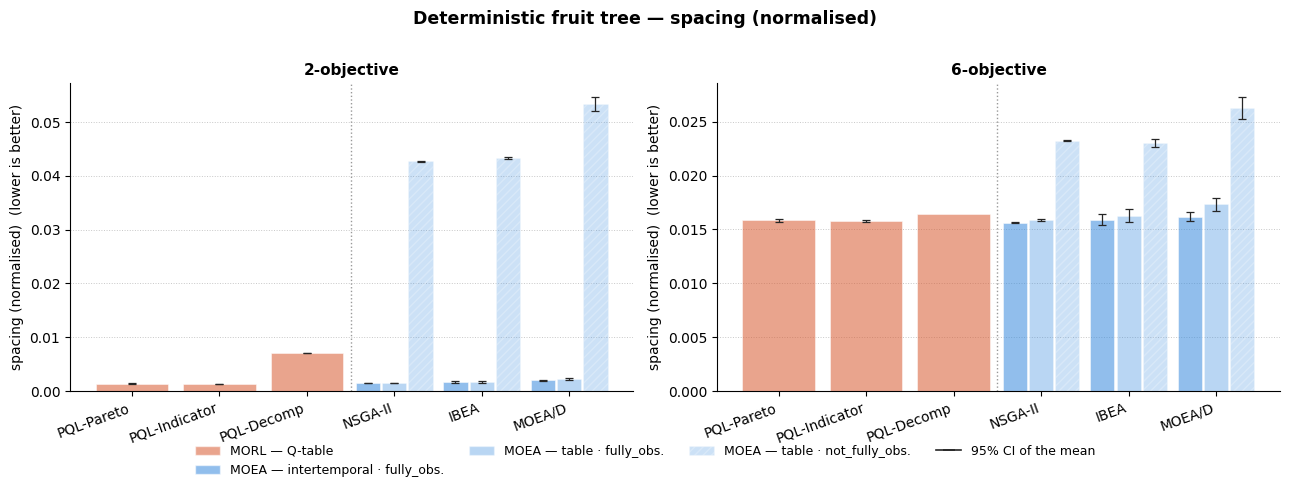

In [4]:
A.figure_metrics_separate(
    df, metrics=METRICS, n_objs=N_OBJS,
    condition_style=CONDITION_STYLE, condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    suptitle='Deterministic fruit tree',
    out_path=os.path.join(OUT_DIR, 'fig3_det_tree.png'))

### Figure 2 — Solution counts


In [5]:
# A.figure_counts(
#     df, n_objs=N_OBJS,
#     condition_style=CONDITION_STYLE,
#     condition_label=CONDITION_LABEL,
#     condition_order=CONDITION_ORDER,
#     suptitle='Number of solutions on the re-evaluated front — '
#              'deterministic fruit tree',
#     out_path=os.path.join(OUT_DIR, 'fig2_det_tree_counts.png'))

### Figure 3 — Convergence (MOEA + MORL)


MOEA: 180 curves; MORL: 60 curves
Saved ./tree_figures/fig18_det_tree_conv_moea.png
Saved ./tree_figures/fig17_det_tree_conv_morl.png


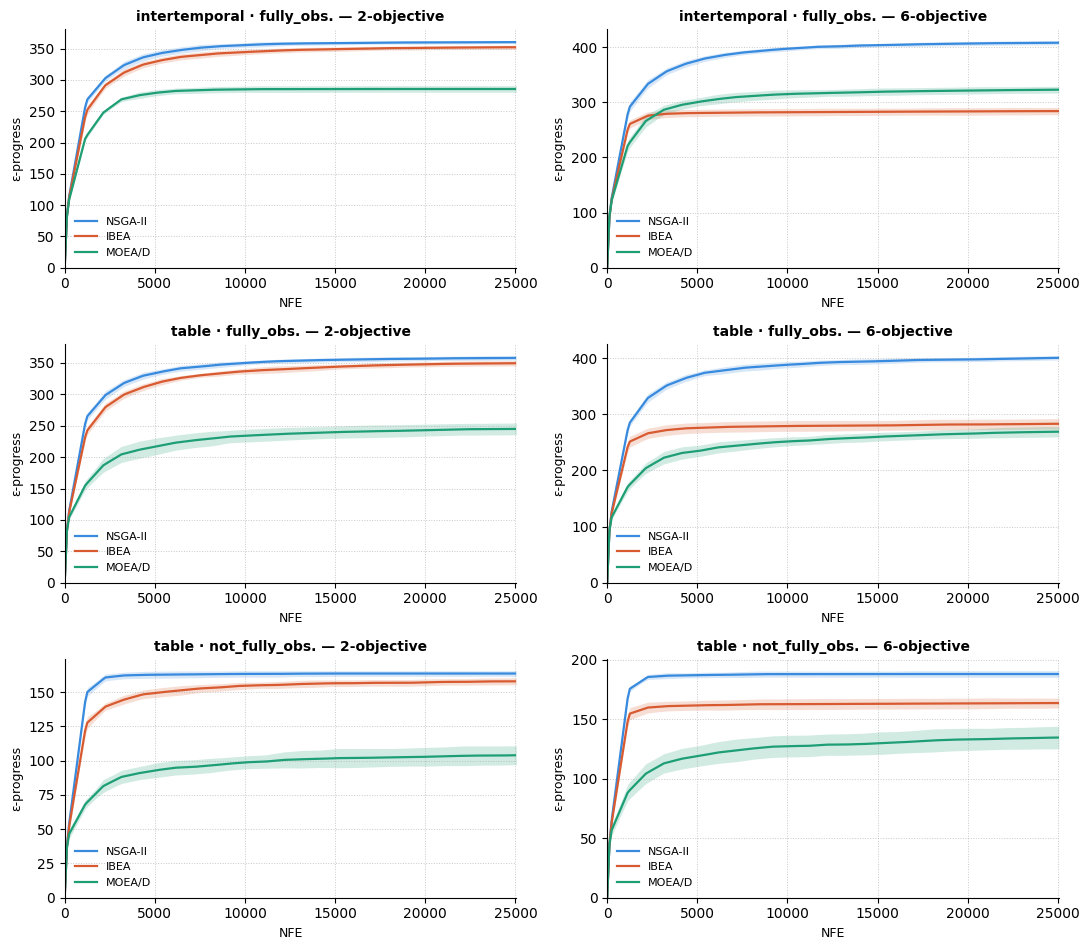

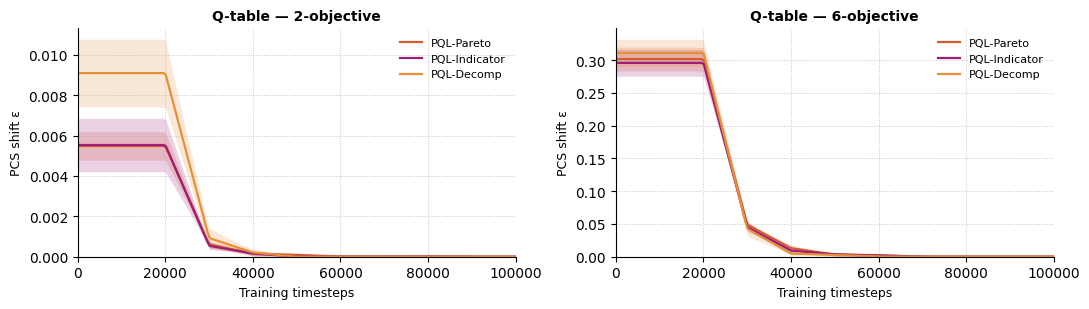

In [6]:
moea_records = A.load_convergences(
    os.path.dirname(MOEA_CSV), folder_re=MOEA_FOLDER_RE,
    condition_format=moea_fmt, csv_prefix='convergences_',
    x_col='nfe', y_col='epsilon_progress')
morl_records = A.load_convergences(
    os.path.dirname(MORL_CSV), folder_re=MORL_FOLDER_RE,
    condition_format=morl_fmt, csv_prefix='convergence_',
    x_col='timestep', y_col='pcs_shift_eps_mean', dropna_y=True)
print(f'MOEA: {len(moea_records)} curves; '
      f'MORL: {len(morl_records)} curves')

A.figure_convergence(
    moea_records,
    methods=MOEA_METHODS,
    conditions=['intertemporal_observable', 'table_observable',
                'table_non_observable'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='NFE', ylabel='ε-progress',
    # suptitle='MOEA convergence — deterministic fruit tree',
    out_path=os.path.join(OUT_DIR, 'fig18_det_tree_conv_moea.png'))

A.figure_convergence(
    morl_records,
    methods=MORL_METHODS,
    conditions=['closed_loop_single'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='Training timesteps',
    ylabel='PCS shift ε',
    # suptitle='MORL convergence — deterministic fruit tree',
    out_path=os.path.join(OUT_DIR, 'fig17_det_tree_conv_morl.png'))

### Runtime summary


In [7]:
rt_rows = (
    A.collect_runtimes(os.path.dirname(MOEA_CSV),
        folder_re=MOEA_FOLDER_RE, paradigm='MOEA',
        condition_format=moea_fmt, csv_prefix='convergences_',
        mode='per_file')
    + A.collect_runtimes(os.path.dirname(MORL_CSV),
        folder_re=MORL_FOLDER_RE, paradigm='MORL',
        condition_format=morl_fmt, csv_prefix='convergence_',
        mode='per_file')
)
rt_df = pd.DataFrame(rt_rows)
print(f'Total runs: {len(rt_df)}')
A.summarize_runtimes(rt_df, title='Deterministic tree runtime', metrics_df=df)

Total runs: 240

=== Deterministic tree runtime ===



,paradigm,method,condition,n_obj,count,mean_hms,std_hms,total_hms,n_dom_mean,n_dom_std,n_solutions_mean,n_solutions_std
0,MOEA,IBEA,intertemporal_observable,2,10,1m19s,0m07s,13m10s,0.0,0.0,345.6,2.0
1,MOEA,IBEA,intertemporal_observable,6,10,4m08s,0m14s,41m20s,0.0,0.0,277.8,7.6
2,MOEA,IBEA,table_non_observable,2,10,5m13s,0m14s,52m10s,0.0,0.0,153.2,1.7
3,MOEA,IBEA,table_non_observable,6,10,8m18s,0m22s,1h23m00s,0.0,0.0,155.6,2.9
4,MOEA,IBEA,table_observable,2,10,5m35s,0m16s,55m50s,0.0,0.0,343.4,4.9
5,MOEA,IBEA,table_observable,6,10,8m16s,0m18s,1h22m40s,0.0,0.0,276.1,9.3
6,MOEA,MOEAD,intertemporal_observable,2,10,1m28s,0m04s,14m40s,0.0,0.0,279.2,4.7
7,MOEA,MOEAD,intertemporal_observable,6,10,2m42s,0m04s,27m00s,0.0,0.0,316.0,8.0
8,MOEA,MOEAD,table_non_observable,2,10,14m31s,0m48s,2h25m10s,0.0,0.0,100.7,6.8
9,MOEA,MOEAD,table_non_observable,6,10,15m38s,0m48s,2h36m20s,0.0,0.0,128.0,9.7


## Robust


### Configuration


In [8]:
MORL_CSV = '../data/tree/robust/morl/metrics_long_reeval.csv'
MOEA_CSV = '../data/tree/robust/moea/metrics_long_reeval.csv'

# Extend the vocabulary with robust-only conditions.
CONDITION_STYLE = {
    'closed_loop_multi':              dict(alpha=0.55, hatch=''),
    'closed_loop_moro':               dict(alpha=0.30, hatch='..'),
    'intertemporal_multi_observable': dict(alpha=0.55, hatch=''),
    'intertemporal_moro_observable':  dict(alpha=0.55, hatch='..'),
    'table_multi_observable':         dict(alpha=0.35, hatch=''),
    'table_moro_observable':          dict(alpha=0.35, hatch='..'),
}
CONDITION_LABEL = {
    'closed_loop_multi':              'Q-table · multi',
    'closed_loop_moro':               'Q-table · RO',
    'intertemporal_multi_observable': 'intertemporal · multi',
    'intertemporal_moro_observable':  'intertemporal · RO',
    'table_multi_observable':         'table · multi',
    'table_moro_observable':          'table · RO',
}
CONDITION_ORDER = [
    'closed_loop_multi', 'closed_loop_moro',
    'intertemporal_multi_observable', 'intertemporal_moro_observable',
    'table_multi_observable',         'table_moro_observable',
]

MOEA_FOLDER_RE = re.compile(
    r'^(intertemporal|table)_(NSGAII|IBEA|MOEAD)_'
    r'(multi|moro)_(\d+)_observable$')
MORL_FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_(multi|moro)_(\d+)$')

def moea_fmt(groups):
    policy, algo, scenm, n_obj = groups
    return f'{policy}_{scenm}_observable', algo, int(n_obj)

def morl_fmt(groups):
    scoring, scenm, n_obj = groups
    return f'closed_loop_{scenm}', scoring, int(n_obj)

### Load + summary


In [9]:
df = A.load_metrics(MORL_CSV, MOEA_CSV, metrics=METRICS)
A.print_metric_summary(df, metrics=METRICS, n_objs=N_OBJS,
                       condition_order=CONDITION_ORDER)

paradigm method        condition                    n_obj    n        n_dom     ±std        hv_ratio      ±std    spacing_norm      ±std
MORL     PQL-Pareto    closed_loop_multi                2   10       1603.1     12.6         0.73619   0.00026         0.00138   0.00041
MORL     PQL-Pareto    closed_loop_moro                 2   10         10.5      5.8         0.59726   0.07408         0.03735   0.03629
MORL     PQL-Indicator closed_loop_multi                2   10       1610.8     13.2         0.73603   0.00036         0.00119   0.00009
MORL     PQL-Indicator closed_loop_moro                 2   10         46.2     12.6         0.56815   0.08456         0.02445   0.03814
MORL     PQL-Decomp    closed_loop_multi                2   10        570.0      0.0         0.73462   0.00000         0.00372   0.00000
MORL     PQL-Decomp    closed_loop_moro                 2   10         28.0      9.5         0.60800   0.04473         0.03218   0.01841
MOEA     NSGA-II       intertemporal_mult

### Figure 1 — HV ratio + spacing (box plots)


Saved ./tree_figures/fig4_robust_tree_metrics_hv_ratio.png
Saved ./tree_figures/fig4_robust_tree_metrics_spacing_norm.png


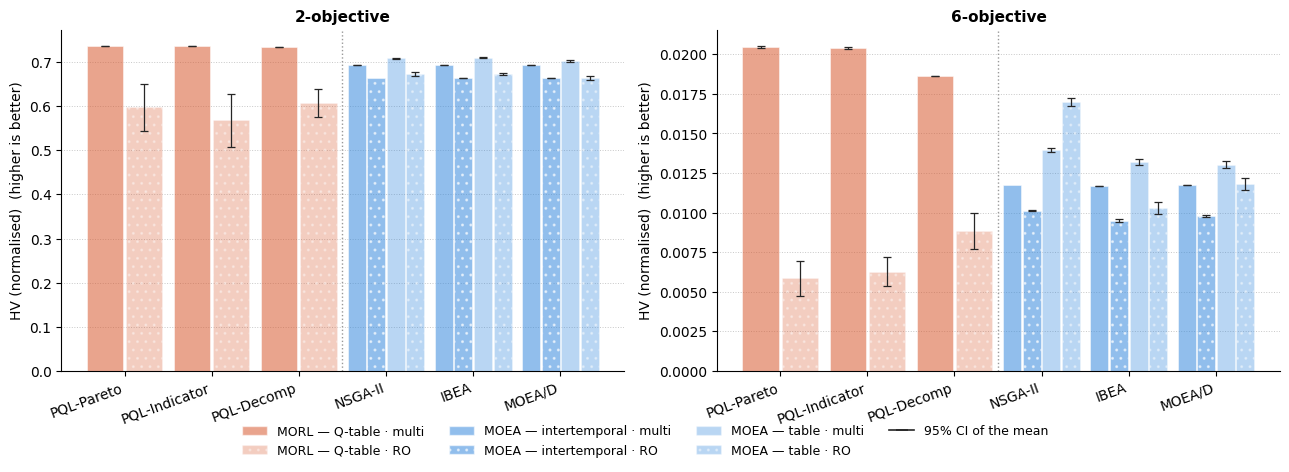

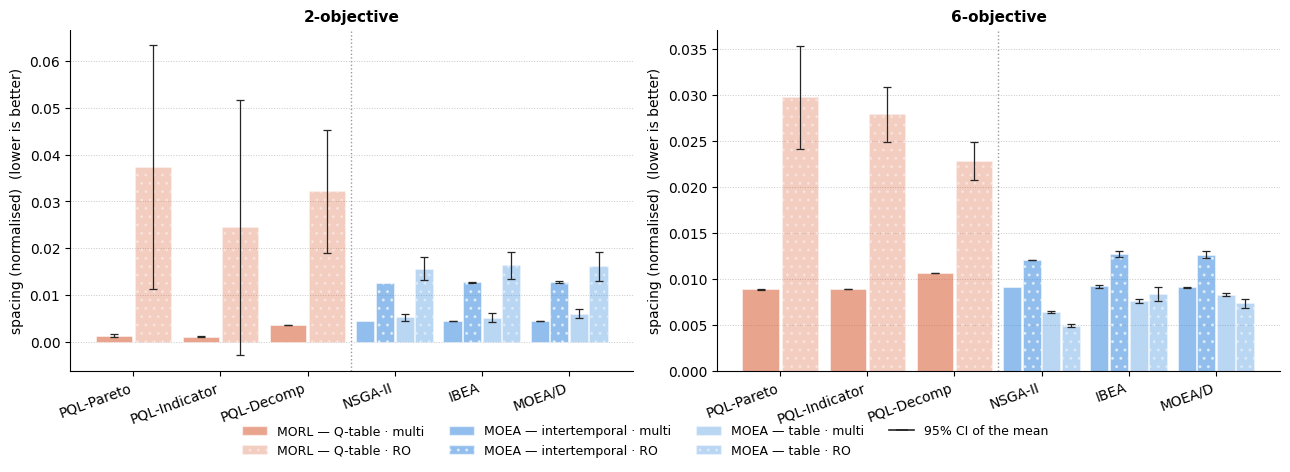

In [10]:
A.figure_metrics_separate(
    df, metrics=METRICS, n_objs=N_OBJS,
    condition_style=CONDITION_STYLE,
    condition_label=CONDITION_LABEL,
    condition_order=CONDITION_ORDER,
    # suptitle='MORL vs MOEA — robust fruit tree (closed-loop)',
    out_path=os.path.join(OUT_DIR, 'fig4_robust_tree_metrics.png'))

### Figure 2 — Solution counts


In [11]:
# A.figure_counts(
#     df, n_objs=N_OBJS,
#     condition_style=CONDITION_STYLE,
#     condition_label=CONDITION_LABEL,
#     condition_order=CONDITION_ORDER,
#     suptitle='Number of solutions on the re-evaluated front — '
#              'robust fruit tree',
#     out_path=os.path.join(OUT_DIR, 'fig2_robust_tree_counts.png'))

### Figure 3 — Convergence (MOEA + MORL)


MOEA: 720 curves; MORL: 360 curves
Saved ./tree_figures/fig20_robust_tree_conv_moea.png
Saved ./tree_figures/fig19_robust_tree_conv_morl.png


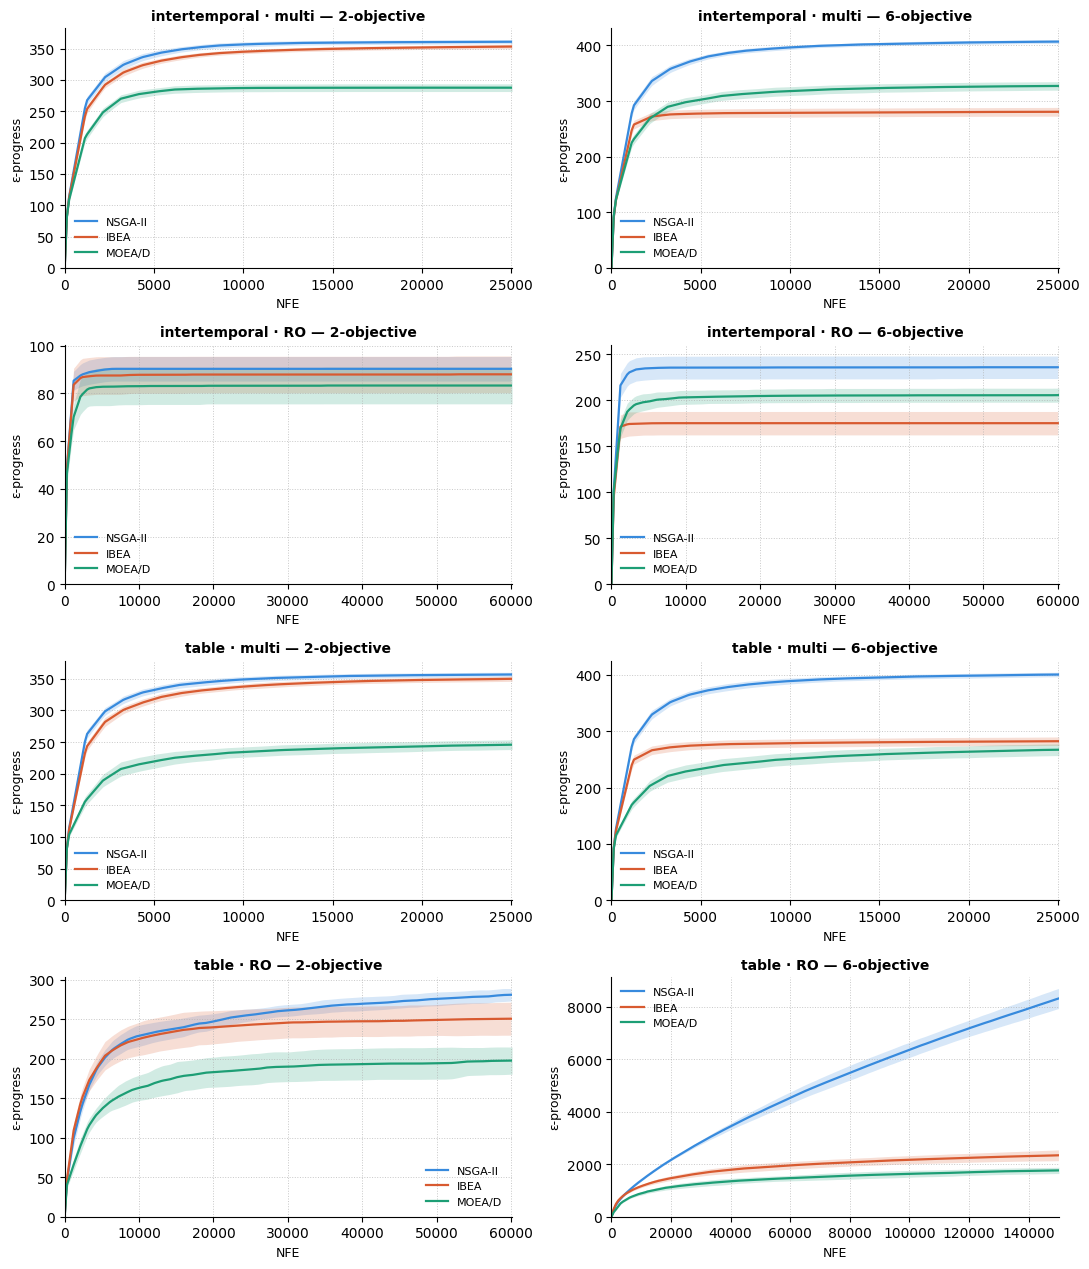

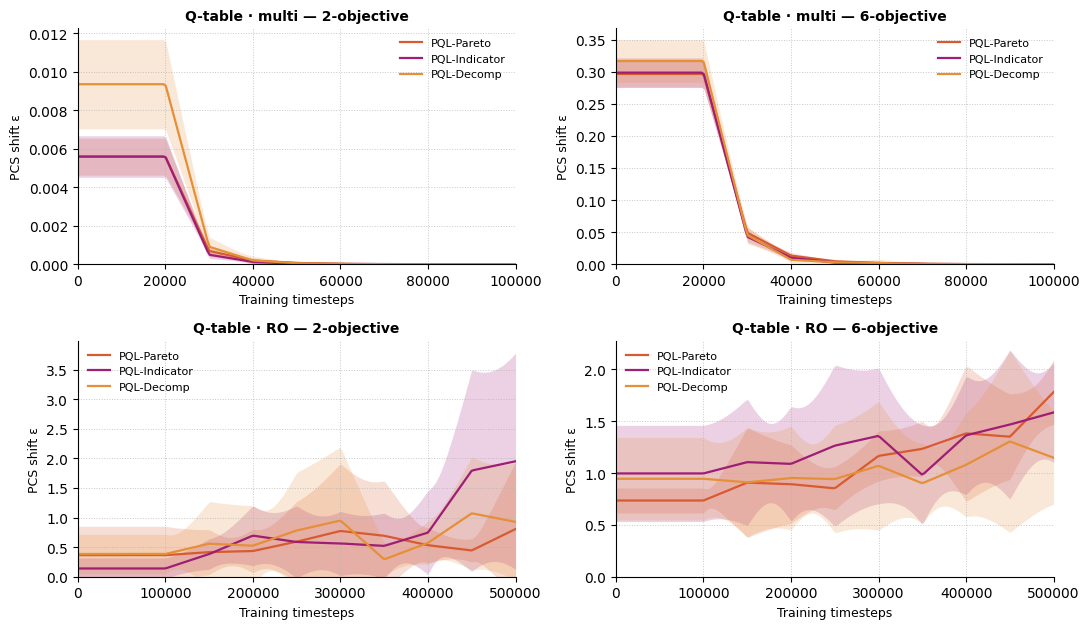

In [12]:
moea_records = A.load_convergences(
    os.path.dirname(MOEA_CSV), folder_re=MOEA_FOLDER_RE,
    condition_format=moea_fmt, csv_prefix='convergences_',
    x_col='nfe', y_col='epsilon_progress')
morl_records = A.load_convergences(
    os.path.dirname(MORL_CSV), folder_re=MORL_FOLDER_RE,
    condition_format=morl_fmt, csv_prefix='convergence_',
    x_col='timestep', y_col='pcs_shift_eps_mean', dropna_y=True)
print(f'MOEA: {len(moea_records)} curves; '
      f'MORL: {len(morl_records)} curves')

A.figure_convergence(
    moea_records,
    methods=MOEA_METHODS,
    conditions=['intertemporal_multi_observable',
                'intertemporal_moro_observable',
                'table_multi_observable',
                'table_moro_observable'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='NFE', ylabel='ε-progress',
    # suptitle='MOEA convergence — robust fruit tree',
    out_path=os.path.join(OUT_DIR, 'fig20_robust_tree_conv_moea.png'))

A.figure_convergence(
    morl_records,
    methods=MORL_METHODS,
    conditions=['closed_loop_multi', 'closed_loop_moro'],
    n_objs=N_OBJS, cond_labels=CONDITION_LABEL,
    xlabel='Training timesteps',
    ylabel='PCS shift ε',
    # suptitle='MORL convergence — robust fruit tree',
    out_path=os.path.join(OUT_DIR, 'fig19_robust_tree_conv_morl.png'))

### Runtime summary


In [13]:
rt_rows = (
    A.collect_runtimes(os.path.dirname(MOEA_CSV),
        folder_re=MOEA_FOLDER_RE, paradigm='MOEA',
        condition_format=moea_fmt, csv_prefix='convergences_',
        mode='per_seed')
    + A.collect_runtimes(os.path.dirname(MORL_CSV),
        folder_re=MORL_FOLDER_RE, paradigm='MORL',
        condition_format=morl_fmt, csv_prefix='convergence_',
        mode='per_seed')
)
rt_df = pd.DataFrame(rt_rows)
print(f'Total runs: {len(rt_df)}')
A.summarize_runtimes(rt_df, title='Robust tree runtime', metrics_df=df)

Total runs: 360

=== Robust tree runtime ===



,paradigm,method,condition,n_obj,count,mean_hms,std_hms,total_hms,n_dom_mean,n_dom_std,n_solutions_mean,n_solutions_std
0,MOEA,IBEA,intertemporal_moro_observable,2,10,7m39s,0m59s,1h16m30s,22.8,1.6,26.6,0.7
1,MOEA,IBEA,intertemporal_moro_observable,6,10,15m54s,0m57s,2h39m00s,3.2,1.2,127.1,6.4
2,MOEA,IBEA,intertemporal_multi_observable,2,10,6m35s,0m23s,1h05m50s,1642.5,5.8,87.9,0.3
3,MOEA,IBEA,intertemporal_multi_observable,6,10,20m40s,0m54s,3h26m40s,1010.7,20.9,365.8,3.5
4,MOEA,IBEA,table_moro_observable,2,10,32m23s,2m09s,5h23m50s,8.1,1.7,17.2,2.0
5,MOEA,IBEA,table_moro_observable,6,10,1h53m09s,10m30s,18h51m30s,27.3,8.2,623.1,71.2
6,MOEA,IBEA,table_multi_observable,2,10,27m44s,1m31s,4h37m20s,1639.9,11.8,74.5,6.4
7,MOEA,IBEA,table_multi_observable,6,10,42m02s,2m04s,7h00m20s,504.5,18.4,872.5,28.2
8,MOEA,MOEAD,intertemporal_moro_observable,2,10,6m44s,0m47s,1h07m20s,21.7,1.9,26.9,0.7
9,MOEA,MOEAD,intertemporal_moro_observable,6,10,9m43s,0m48s,1h37m10s,4.5,0.8,148.5,5.7
